# Stage 2: Scene-Specific Neural LOD Threshold Baker - Training Notebook

**Purpose**: Train an MLP regressor that maps camera pose (position + orientation) to optimal per-object LOD threshold vectors.

**Input data**: CSV files exported by the Unity `BakerOrchestrator` pipeline:
- `sample_records.csv` - performance measurements per (point, rotation, LOD level)
- `labels.csv` - oracle-optimal threshold vectors per viewpoint
- `grid_points.csv` - grid point coordinates
- `lod_objects.csv` - baseline LOD object metadata

**Output**: Trained ONNX model + scaler constants JSON for Unity deployment.

---


In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

Paths are relative to `ml_pipeline/` root. Adjust `DATA_DIR` if your BakerExport folder is elsewhere.


In [54]:
# paths relative to ml_pipeline root
BASE_DIR = Path("../..").resolve()  # ml_pipeline/
DATA_DIR = BASE_DIR / "data" / "Baker"  # where Unity exports land
MODEL_DIR = BASE_DIR / "models" / "baker"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# file names from DatasetExporter.cs
SAMPLES_FILE = DATA_DIR / "sample_records.csv"
LABELS_FILE = DATA_DIR / "labels.csv"
GRID_FILE = DATA_DIR / "grid_points.csv"
OBJECTS_FILE = DATA_DIR / "lod_objects.csv"

# training hyperparameters
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 20  # early stopping
HIDDEN_1 = 128
HIDDEN_2 = 64
HIDDEN_3 = 32
DROPOUT = 0.1
TEST_SPLIT = 0.2
VAL_SPLIT = 0.1  # of training set
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Data dir: {DATA_DIR}")
print(f"Model dir: {MODEL_DIR}")
for f in [SAMPLES_FILE, LABELS_FILE, GRID_FILE, OBJECTS_FILE]:
    status = "FOUND" if f.exists() else "MISSING"
    print(f"  {f.name}: {status}")


Data dir: C:\Users\Gica\neural-lod\ml_pipeline\data\Baker
Model dir: C:\Users\Gica\neural-lod\ml_pipeline\models\baker
  sample_records.csv: FOUND
  labels.csv: FOUND
  grid_points.csv: FOUND
  lod_objects.csv: FOUND


## 2. Load and inspect data


In [55]:
# load CSVs
df_samples = pd.read_csv(SAMPLES_FILE)
df_labels = pd.read_csv(LABELS_FILE)
df_grid = pd.read_csv(GRID_FILE)
df_objects = pd.read_csv(OBJECTS_FILE)

print(f"Sample records: {len(df_samples):,} rows")
print(f"Labels: {len(df_labels):,} rows")
print(f"Grid points: {len(df_grid):,}")
print(f"LOD objects: {len(df_objects):,}")

print("\n--- Sample records columns ---")
print(df_samples.columns.tolist())
print(df_samples.head())

print("\n--- Labels columns ---")
print(df_labels.columns.tolist())
print(df_labels.head())


Sample records: 72,000 rows
Labels: 18,000 rows
Grid points: 500
LOD objects: 14,752

--- Sample records columns ---
['point_id', 'rot_x', 'rot_y', 'rot_z', 'lod_level', 'mean_gpu_ms', 'mean_cpu_ms', 'mean_fps']
   point_id  rot_x  rot_y  rot_z  lod_level  mean_gpu_ms  mean_cpu_ms  \
0         0    -60      0    -30          0     4.745387     1.906500   
1         0    -60      0    -30          1     1.843836     2.285348   
2         0    -60      0    -30          2     1.835486     1.833290   
3         0    -60      0    -30          3     1.869005     1.962234   
4         0    -60      0      0          0     1.823320     2.496221   

   mean_fps  
0  210.7310  
1  437.5701  
2  544.8149  
3  509.6233  
4  400.6056  

--- Labels columns ---
['point_id', 'rot_x', 'rot_y', 'rot_z', 'optimal_thresholds']
   point_id  rot_x  rot_y  rot_z  optimal_thresholds
0         0    -60      0    -30            0.666667
1         0    -60      0      0            1.000000
2         0    -60  

## 3. Parse and prepare features/targets

The `optimal_thresholds` column contains semicolon-separated float vectors. We parse these into fixed-width arrays.


In [56]:
# parse optimal_thresholds from semicolon-separated string to list of floats
df_labels["thresh_parsed"] = df_labels["optimal_thresholds"].apply(
    lambda s: [float(v) for v in str(s).split(";")] if pd.notna(s) else []
)

# determine output dimension (number of thresholds per prediction)
thresh_lengths = df_labels["thresh_parsed"].apply(len)
OUTPUT_DIM = int(thresh_lengths.mode().iloc[0])
print(f"Output dimension (thresholds per sample): {OUTPUT_DIM}")

# filter rows with correct length
mask = thresh_lengths == OUTPUT_DIM
df_labels_clean = df_labels[mask].copy()
print(f"Labels after filtering: {len(df_labels_clean):,} / {len(df_labels):,}")

# build target matrix
targets = np.array(df_labels_clean["thresh_parsed"].tolist(), dtype=np.float32)
print(f"Target shape: {targets.shape}")
print(f"Target range: [{targets.min():.4f}, {targets.max():.4f}]")


Output dimension (thresholds per sample): 1
Labels after filtering: 18,000 / 18,000
Target shape: (18000, 1)
Target range: [0.0000, 1.0000]


In [57]:
# features: position (x,y,z) + rotation sin/cos encoding
# this matches what LODThresholdPredictor.cs sends at runtime

positions = df_labels_clean[["rot_x", "rot_y", "rot_z"]].values.astype(np.float32)

# get grid point coordinates for each label
grid_lookup = df_grid.set_index("point_id")[["x", "y", "z"]]
point_coords = df_labels_clean["point_id"].map(
    lambda pid: grid_lookup.loc[pid].values if pid in grid_lookup.index else np.zeros(3)
)
point_coords = np.array(point_coords.tolist(), dtype=np.float32)

# rotation encoding: sin/cos of each euler angle (in degrees)
rot_rad = np.deg2rad(positions)
sin_rot = np.sin(rot_rad)
cos_rot = np.cos(rot_rad)

# assemble feature matrix: pos_x, pos_y, pos_z, sin_rx, cos_rx, sin_ry, cos_ry, sin_rz, cos_rz
features = np.hstack([
    point_coords,       # 3: x, y, z
    sin_rot[:, 0:1],    # sin(pitch)
    cos_rot[:, 0:1],    # cos(pitch)
    sin_rot[:, 1:2],    # sin(yaw)
    cos_rot[:, 1:2],    # cos(yaw)
    sin_rot[:, 2:3],    # sin(roll)
    cos_rot[:, 2:3],    # cos(roll)
])

INPUT_DIM = features.shape[1]
print(f"Feature matrix shape: {features.shape}")
print(f"Input dimension: {INPUT_DIM}")

feature_names = [
    "pos_x", "pos_y", "pos_z",
    "sin_pitch", "cos_pitch",
    "sin_yaw", "cos_yaw",
    "sin_roll", "cos_roll"
]
print(f"Feature names: {feature_names}")


Feature matrix shape: (18000, 9)
Input dimension: 9
Feature names: ['pos_x', 'pos_y', 'pos_z', 'sin_pitch', 'cos_pitch', 'sin_yaw', 'cos_yaw', 'sin_roll', 'cos_roll']


## 4. Normalize features and split dataset


In [58]:
# normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features).astype(np.float32)

# save scaler constants for Unity deployment
scaler_dict = {
    "feature_names": feature_names,
    "mean":  scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "input_dim":  int(INPUT_DIM),
    "output_dim": int(OUTPUT_DIM)
}
scaler_path = MODEL_DIR / "baker_scaler_constants.json"
with open(scaler_path, "w") as f:
    json.dump(scaler_dict, f, indent=2)
print(f"Scaler constants saved to: {scaler_path}")

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, targets,
    test_size=TEST_SPLIT,
    random_state=RANDOM_SEED
)

# train/val split from training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SPLIT,
    random_state=RANDOM_SEED
)

print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")


Scaler constants saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker\baker_scaler_constants.json
Train: 12,960
Val:   1,440
Test:  3,600


## 5. PyTorch dataset and model definition


In [59]:
class BakerDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = BakerDataset(X_train, y_train)
val_ds = BakerDataset(X_val, y_val)
test_ds = BakerDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 51
Val batches: 6
Test batches: 15


In [60]:
class BakerMLP(nn.Module):
    # MLP regressor: pose features -> optimal threshold vector
    def __init__(self, input_dim, output_dim, h1, h2, h3, dropout):
        super(BakerMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, output_dim),
            nn.Sigmoid()  # thresholds are in [0, 1]
        )

    def forward(self, x):
        return self.net(x)

model = BakerMLP(INPUT_DIM, OUTPUT_DIM, HIDDEN_1, HIDDEN_2, HIDDEN_3, DROPOUT).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


BakerMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
Total parameters: 11,649


## 6. Training loop with early stopping


In [61]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    # train
    model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * X_batch.size(0)
    epoch_train_loss /= len(train_ds)

    # validate
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)
    epoch_val_loss /= len(val_ds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    # early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {epoch_train_loss:.6f} | "
              f"Val: {epoch_val_loss:.6f} | "
              f"Best: {best_val_loss:.6f} | "
              f"Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# restore best model
model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")


Epoch   1/200 | Train: 0.177230 | Val: 0.127557 | Best: 0.127557 | Patience: 0/20
Epoch   2/200 | Train: 0.109426 | Val: 0.087446 | Best: 0.087446 | Patience: 0/20
Epoch   3/200 | Train: 0.087589 | Val: 0.075348 | Best: 0.075348 | Patience: 0/20
Epoch   4/200 | Train: 0.078263 | Val: 0.069462 | Best: 0.069462 | Patience: 0/20
Epoch   5/200 | Train: 0.074277 | Val: 0.065686 | Best: 0.065686 | Patience: 0/20
Epoch   6/200 | Train: 0.070228 | Val: 0.063388 | Best: 0.063388 | Patience: 0/20
Epoch   7/200 | Train: 0.066731 | Val: 0.059793 | Best: 0.059793 | Patience: 0/20
Epoch   8/200 | Train: 0.065393 | Val: 0.058725 | Best: 0.058725 | Patience: 0/20
Epoch   9/200 | Train: 0.063808 | Val: 0.057445 | Best: 0.057445 | Patience: 0/20
Epoch  10/200 | Train: 0.061798 | Val: 0.055928 | Best: 0.055928 | Patience: 0/20
Epoch  12/200 | Train: 0.059187 | Val: 0.054357 | Best: 0.054357 | Patience: 0/20
Epoch  13/200 | Train: 0.058143 | Val: 0.053534 | Best: 0.053534 | Patience: 0/20
Epoch  16/200 | 

## 7. Training diagnostics


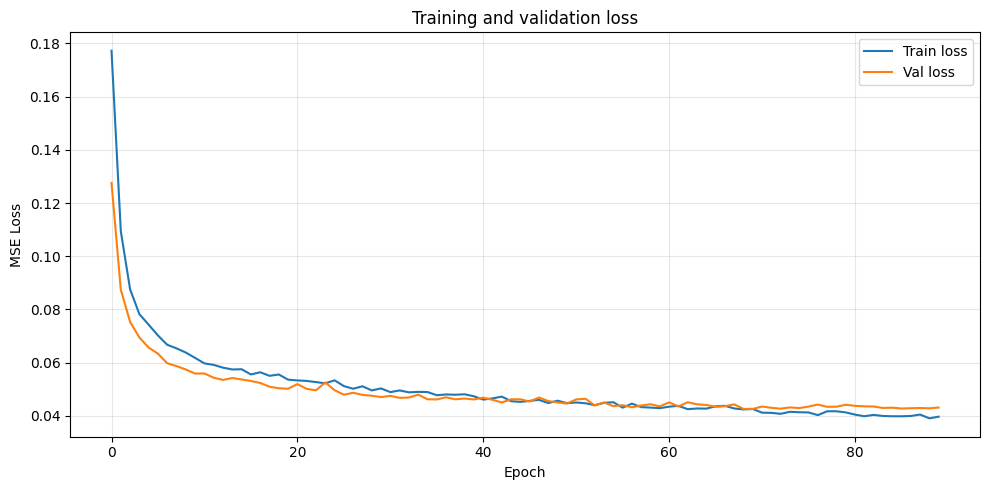

Loss curve saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker\baker_loss_curve.png


In [62]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label="Train loss", linewidth=1.5)
ax.plot(val_losses, label="Val loss", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / "baker_loss_curve.png"), dpi=150)
plt.show()
print(f"Loss curve saved to: {MODEL_DIR / 'baker_loss_curve.png'}")


## 8. Test set evaluation


In [63]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())

preds = np.concatenate(all_preds, axis=0)
truths = np.concatenate(all_targets, axis=0)

# per-output metrics
print("Per-threshold metrics:")
print(f"{'Threshold':<12} {'MAE':>8} {'RMSE':>8}")
print("-" * 30)
for i in range(OUTPUT_DIM):
    mae = mean_absolute_error(truths[:, i], preds[:, i])
    rmse = np.sqrt(mean_squared_error(truths[:, i], preds[:, i]))
    print(f"  thresh_{i:<4} {mae:>8.4f} {rmse:>8.4f}")

# aggregate metrics
overall_mae = mean_absolute_error(truths.flatten(), preds.flatten())
overall_rmse = np.sqrt(mean_squared_error(truths.flatten(), preds.flatten()))
print(f"\nOverall MAE:  {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")


Per-threshold metrics:
Threshold         MAE     RMSE
------------------------------
  thresh_0      0.1040   0.2052

Overall MAE:  0.1040
Overall RMSE: 0.2052


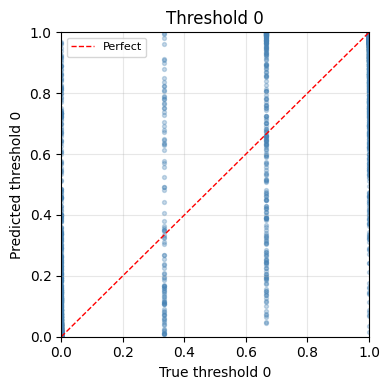

In [64]:
fig, axes = plt.subplots(1, min(OUTPUT_DIM, 4), figsize=(4 * min(OUTPUT_DIM, 4), 4))
if OUTPUT_DIM == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    if i >= OUTPUT_DIM:
        break
    ax.scatter(truths[:, i], preds[:, i], alpha=0.3, s=8, c="steelblue")
    ax.plot([0, 1], [0, 1], "r--", linewidth=1, label="Perfect")
    ax.set_xlabel(f"True threshold {i}")
    ax.set_ylabel(f"Predicted threshold {i}")
    ax.set_title(f"Threshold {i}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / "baker_pred_vs_true.png"), dpi=150)
plt.show()


## 9. Feature importance (permutation)


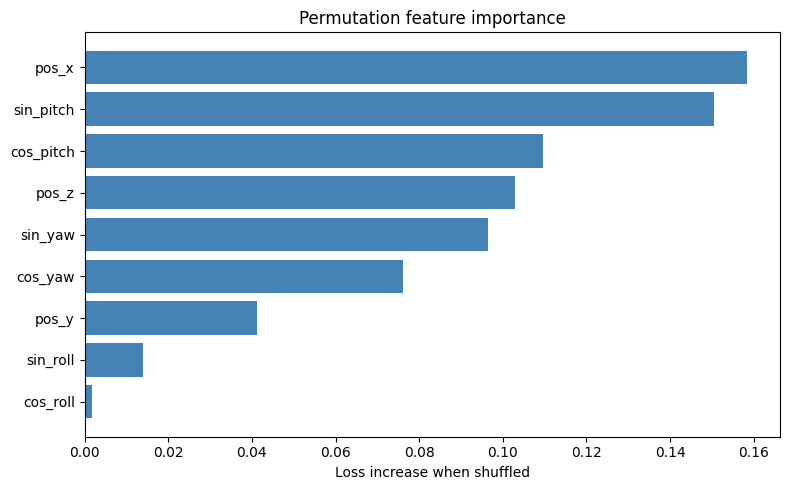

In [65]:
# permutation importance on test set
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    base_loss = criterion(model(X_test_t), y_test_t).item()

importances = []
for i in range(INPUT_DIM):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(device)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importances.append(perm_loss - base_loss)

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = np.argsort(importances)[::-1]
ax.barh(
    [feature_names[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color="steelblue"
)
ax.set_xlabel("Loss increase when shuffled")
ax.set_title("Permutation feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / "baker_feature_importance.png"), dpi=150)
plt.show()


## 10. Export model


In [66]:
# save PyTorch checkpoint
pt_path = MODEL_DIR / "baker_best_model.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": INPUT_DIM,
    "output_dim": OUTPUT_DIM,
    "hidden_1": HIDDEN_1,
    "hidden_2": HIDDEN_2,
    "hidden_3": HIDDEN_3,
    "dropout": DROPOUT,
    "best_val_loss": best_val_loss,
    "feature_names": feature_names,
}, pt_path)
print(f"PyTorch model saved: {pt_path}")


PyTorch model saved: C:\Users\Gica\neural-lod\ml_pipeline\models\baker\baker_best_model.pt


In [67]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)
onnx_path = MODEL_DIR / "lod_baker.onnx"

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=15,
    input_names=["features"],
    output_names=["thresholds"],
    dynamic_axes={
        "features":   {0: "batch_size"},
        "thresholds": {0: "batch_size"}
    }
)

C:\Users\Gica\AppData\Local\Temp\ipykernel_31896\1244390934.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 11:30:28.000000 31896 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `BakerMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BakerMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\Gica\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).
Failed to convert the model to the target version 15 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\Gica\neural-lod\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Gica\neural-lod\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\Gica\neura

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"features"<FLOAT,[batch_size,9]>
            ),
            outputs=(
                %"thresholds"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"net.0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.3.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"net.6.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"net.8.weight"<FLOAT,[1,32]>{TorchTensor(...)},
                %"net.8.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([-0.0023], requires_grad=True), name='net.8.bias')},
                %"net.0.weight"<FLOAT,[128,9]>{TorchTensor(...)},
                %"net.3.weight"<FLOAT,[64,128]>{T

In [68]:
# verify ONNX model loads correctly
try:
    import onnx
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)
    print("ONNX model verification: PASSED")
    print(f"  Inputs:  {[i.name for i in onnx_model.graph.input]}")
    print(f"  Outputs: {[o.name for o in onnx_model.graph.output]}")
except ImportError:
    print("onnx package not installed, skipping verification")
    print("Install with: pip install onnx")
except Exception as e:
    print(f"ONNX verification FAILED: {e}")


ONNX model verification: PASSED
  Inputs:  ['features']
  Outputs: ['thresholds']


## 11. Deployment to Unity

**Files to copy to Unity project:**

| File | Destination |
|------|------------|
| `lod_baker.onnx` | `Assets/StreamingAssets/` |
| `baker_scaler_constants.json` | `Assets/StreamingAssets/` |

**Unity setup:**
1. Update `LODThresholdPredictor.cs` field `modelFileName` to `"lod_baker.onnx"`
2. The predictor builds a 9-feature vector: `[pos_x, pos_y, pos_z, sin_pitch, cos_pitch, sin_yaw, cos_yaw, sin_roll, cos_roll]`
3. Features must be normalized using the means/stds from `baker_scaler_constants.json`
4. Model output is a vector of `OUTPUT_DIM` floats in [0, 1], applied directly as `screenRelativeTransitionHeight` values

**Metrics summary is printed above in section 8.**


In [69]:
onnx_size = os.path.getsize(onnx_path)

print("=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"Input features:   {INPUT_DIM}")
print(f"Output thresholds: {OUTPUT_DIM}")
print(f"Best val loss:    {best_val_loss:.6f}")
print(f"Test MAE:         {overall_mae:.4f}")
print(f"Test RMSE:        {overall_rmse:.4f}")
print(f"Model params:     {total_params:,}")
print(f"ONNX size:        {onnx_size / 1024:.1f} KB")
print(f"\nFiles saved in: {MODEL_DIR}")
for f in MODEL_DIR.iterdir():
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")


TRAINING COMPLETE
Input features:   9
Output thresholds: 1
Best val loss:    0.042627
Test MAE:         0.1040
Test RMSE:        0.2052
Model params:     11,649
ONNX size:        11.9 KB

Files saved in: C:\Users\Gica\neural-lod\ml_pipeline\models\baker
  baker_best_model.pt (49.5 KB)
  baker_feature_importance.png (31.8 KB)
  baker_loss_curve.png (57.2 KB)
  baker_pred_vs_true.png (53.6 KB)
  baker_scaler_constants.json (0.7 KB)
  lod_baker.onnx (11.9 KB)
  lod_baker.onnx.data (45.0 KB)
